# Python-Spickzettel für Übung 1

Dieser Spickzettel dient nur als kurze Einführung vor der Übung.  
Er verwendet keine Daten und keine Aufgaben aus der eigentlichen Übung.

Die Erklärungen stehen in Markdown-Zellen. Die Code-Zellen darunter können einzeln ausgeführt werden.


## 1. Bibliotheken importieren

In Python werden Bibliotheken meistens am Anfang importiert.

**pandas** wird für Tabellen verwendet. Eine Tabelle heißt in pandas meistens `DataFrame`.  
**numpy** wird für numerische Hilfsfunktionen verwendet.  
**matplotlib.pyplot** wird zum Zeichnen von Diagrammen verwendet.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Kleine Beispieltabelle erzeugen

Diese Zelle erzeugt nur neutrale Beispieldaten, damit die folgenden Befehle ausprobiert werden können.  
Die Daten haben nichts mit der eigentlichen Übung zu tun.


In [2]:
rng = np.random.default_rng(0)  # erzeugt Zufallszahlen, durch die 0 als Startwert entstehen bei jeder Ausführung dieselben Zahlen

zeit = pd.date_range( # erstellt eine Zeitreihe mit regelmäßigen, gleichen Abständen
    start="2024-01-01",  # erster Zeitpunkt der Zeitreihe
    periods=24,  # Anzahl der erzeugten Zeitpunkte
    freq="h"  # zeitlicher Abstand zwischen den Zeitpunkten: hier stündlich
)

df = pd.DataFrame(  # erstellt eine Tabelle aus den folgenden Spalten
    {
        "Zeit": zeit,  # Zeitspalte mit 24 stündlichen Zeitpunkten
        "Temperatur": rng.normal(20, 3, 24),  # 24 Temperaturwerte um 20 mit Standardabweichung 3
        "Messwert_A": rng.uniform(0, 100, 24),  # 24 zufällige Werte zwischen 0 und 100
        "Messwert_B": rng.uniform(0, 50, 24),  # 24 zufällige Werte zwischen 0 und 50
        "Wind": rng.uniform(0, 10, 24),  # 24 zufällige Windwerte zwischen 0 und 10
    }
)


## 3. CSV-Dateien einlesen

Mit `pd.read_csv(...)` kann eine Textdatei mit tabellarischen Daten eingelesen werden.

Beispiel:

```python
pd.read_csv("dateiname.csv")
```

Der Befehl ist hier nur als Lesebeispiel gedacht und wird nicht ausgeführt, weil keine echte Datei verwendet werden soll.

Weitere Dateiformate können auch eingelesen werden, z.B. mit: `pd.read_excel(...)`, `pd.read_html(...)`, `pd.read_xml(...)`, `pd.read_json(...)` 


## 4. Tabelle anschauen

`df.head()` zeigt die ersten Zeilen einer Tabelle. Das ist praktisch, um schnell zu prüfen, ob die Daten sinnvoll aussehen.


In [3]:
df.head()


,Zeit,Temperatur,Messwert_A,Messwert_B,Wind
0,2024-01-01 00:00:00,20.377191,61.538511,4.200767,4.403772
1,2024-01-01 01:00:00,19.603685,38.367755,41.632207,9.545905
2,2024-01-01 02:00:00,21.921268,99.720994,39.354915,4.998958
3,2024-01-01 03:00:00,20.314700,98.083534,11.968472,4.252286
4,2024-01-01 04:00:00,18.392992,68.554198,43.824212,6.202135


`df.shape` gibt die Größe der Tabelle aus. Der erste Wert ist die Anzahl der Zeilen, der zweite Wert die Anzahl der Spalten.


In [4]:
df.shape


(24, 5)

`df.columns` zeigt die Namen der Spalten.


In [5]:
df.columns


Index(['Zeit', 'Temperatur', 'Messwert_A', 'Messwert_B', 'Wind'], dtype='str')

## 5. Spalten auswählen

Mit eckigen Klammern kann eine einzelne Spalte ausgewählt werden.


In [6]:
df["Temperatur"]


0     20.377191
1     19.603685
2     21.921268
3     20.314700
4     18.392992
5     21.084785
6     23.912000
7     22.841243
8     17.888794
9     16.203736
10    18.130177
11    20.123978
12    13.024908
13    19.343625
14    16.262267
15    17.803198
16    18.367223
17    19.051100
18    21.234892
19    23.127540
20    19.614396
21    24.099390
22    18.004416
23    21.054530
Name: Temperatur, dtype: float64

Mit einer Liste in eckigen Klammern können mehrere Spalten ausgewählt werden.


In [7]:
df[["Temperatur", "Wind"]]


,Temperatur,Wind
0,20.377191,4.403772
1,19.603685,9.545905
2,21.921268,4.998958
3,20.314700,4.252286
4,18.392992,6.202135
5,21.084785,9.950965
6,23.912000,9.489437
7,22.841243,4.600451
8,17.888794,7.577288
9,16.203736,4.974227


`filter(like=...)` wählt Spalten aus, deren Name einen bestimmten Text enthält.


In [8]:
df.filter(like="Messwert")


,Messwert_A,Messwert_B
0,61.538511,4.200767
1,38.367755,41.632207
2,99.720994,39.354915
3,98.083534,11.968472
4,68.554198,43.824212
5,65.045928,2.928402
6,68.844673,16.805853
7,38.892142,7.513973
8,13.509651,22.516968
9,72.148834,39.816214


## 6. Einfache Kennwerte berechnen

Viele statistische Kennwerte können direkt auf eine Spalte angewendet werden.


In [9]:
df["Temperatur"].min()


np.float64(13.024907676083497)

In [10]:
df["Temperatur"].max()


np.float64(24.099390411649058)

In [11]:
df["Temperatur"].mean()


np.float64(19.65758473195469)

In [12]:
df["Temperatur"].std()


np.float64(2.6009362605638664)

Bei mehreren ausgewählten Spalten wird der Kennwert für jede Spalte berechnet.


In [13]:
df[["Messwert_A", "Messwert_B"]].sum()


Messwert_A    1370.766887
Messwert_B     515.362061
dtype: float64

## 7. Mit Zeitreihen arbeiten

Wenn eine Spalte Zeitpunkte enthält, kann sie als Index verwendet werden.  
Das ist hilfreich, wenn Daten zeitlich zusammengefasst werden sollen.


In [14]:
df_zeit = df.set_index("Zeit")


`resample(...)` gruppiert Zeitreihen nach einem Zeitintervall.  
`"D"` steht zum Beispiel für tageweise Gruppierung.


In [15]:
df_zeit.resample("D").mean()


,Temperatur,Messwert_A,Messwert_B,Wind
Zeit,,,,
2024-01-01,19.657585,57.115287,21.473419,6.776263


## 8. Ein einfaches Diagramm erstellen

Mit `.plot()` kann eine Spalte schnell als Liniendiagramm dargestellt werden.


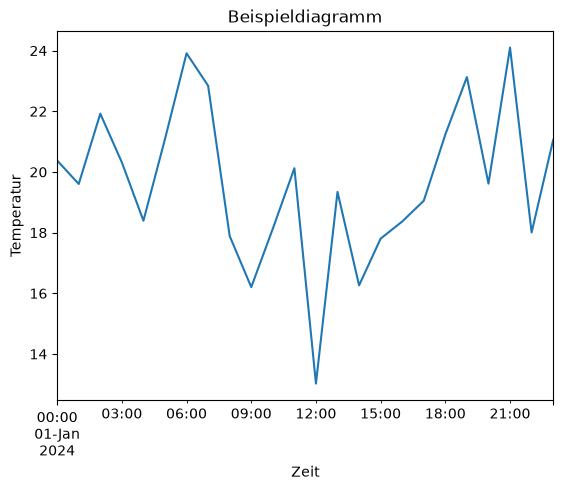

In [16]:
df_zeit["Temperatur"].plot()  # zeichnet die Werte der Spalte "Temperatur" gegen den Index (hier: Zeit)
plt.xlabel("Zeit")  # Name der x-Achse
plt.ylabel("Temperatur")  # Name der y-Achse
plt.title("Beispieldiagramm")  # Überschrift des Diagramms
plt.show()  # stellt das Diagramm dar


## 9. Ein Histogramm erstellen

Ein Histogramm zeigt, wie häufig bestimmte Wertebereiche vorkommen.


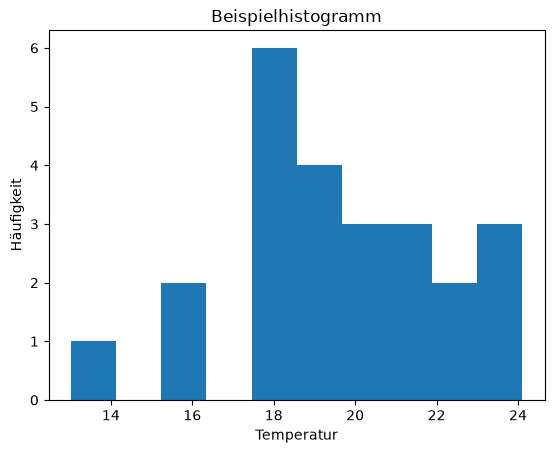

In [17]:
df_zeit["Temperatur"].plot.hist(bins=10)  # zeigt, wie häufig bestimmte Temperaturbereiche vorkommen; die Daten werden in 10 Intervalle eingeteilt
plt.xlabel("Temperatur")  # Wertebereich der Temperatur
plt.ylabel("Häufigkeit")  # Anzahl der Messwerte in jedem Intervall
plt.title("Beispielhistogramm")  # Titel des Histogramms
plt.show()  # zeigt das Diagramm an


## 10. Kurze Schleife über Spaltennamen

Eine `for`-Schleife kann verwendet werden, um mehrere ähnliche Dinge nacheinander zu bearbeiten.  
Hier werden nur die Spaltennamen ausgegeben.


In [18]:
for spalte in df.columns:
    print(spalte)


Zeit
Temperatur
Messwert_A
Messwert_B
Wind


## Ende

Dieser Spickzettel zeigt nur die grundlegende Bedienung der wichtigsten Funktionen.  
Die eigentliche Anwendung auf reale Wetterdaten passiert erst in der Übung.
